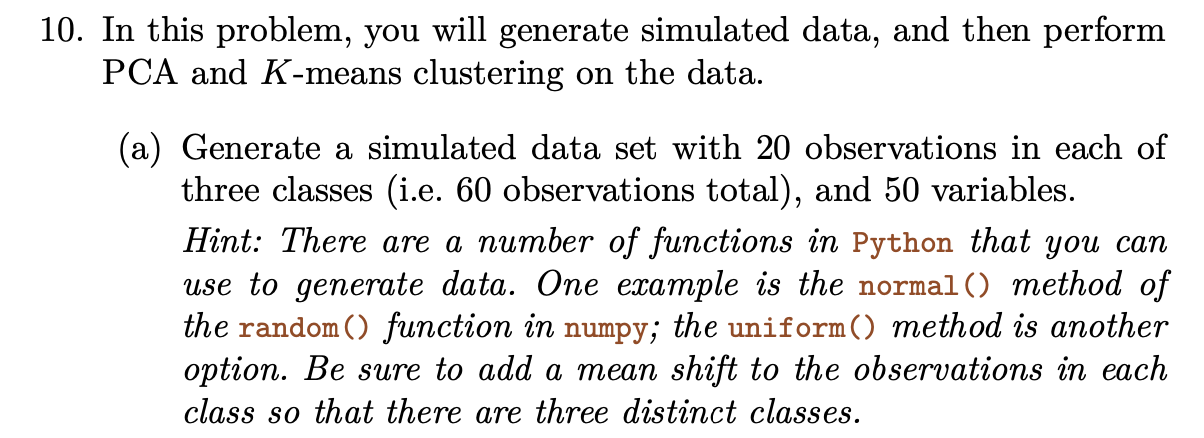

In [ ]:
import numpy as np
import pandas as pd

classes = 3
n = 20
variables = 50
sep = 4

xs = []
ys = []
for i in range(classes):
  mean_shift = i*sep
  x_i = np.random.normal(loc=mean_shift, scale=1.0, size=(n, variables))
  xs.append(x_i)
  ys.append(np.full(n, i))

x=np.vstack(xs)
y=np.concatenate(ys)
df = pd.DataFrame(x, columns=[f"x{j+1}" for j in range(variables)])
df.head()

,x1,x2,x3,x4,x5,x6,x7,x8,x9,x10,...,x41,x42,x43,x44,x45,x46,x47,x48,x49,x50
0,-0.933575,0.028104,0.332437,-1.056339,0.759137,-0.817809,-1.510946,0.076134,-0.082156,-0.001022,...,-1.233672,0.272957,-0.197840,0.101806,-0.395804,-0.419260,0.154781,-1.002138,-1.008022,-0.358549
1,-0.397470,-1.005396,0.924215,-0.334473,-0.226662,-1.327528,2.071636,2.427067,-0.780399,1.226086,...,-0.229281,1.037275,0.087341,0.484597,0.141601,-1.115434,0.017270,0.130782,0.759923,-1.068588
2,-2.040411,0.176264,0.353850,-0.179385,0.028021,0.878772,-0.458806,-0.278641,0.079036,-1.219815,...,-0.776516,-1.169024,-1.653814,-0.010840,0.705101,0.954034,-0.474476,-0.271904,0.355677,-0.108486
3,0.810607,0.430365,-0.376304,-1.856636,1.499032,-0.686082,0.357559,-1.916592,-0.011317,0.100262,...,1.194660,-0.312592,-1.245902,-0.209660,-0.566569,0.552179,-0.337905,-2.710567,3.691625,0.142363
4,0.089192,-1.541410,-1.464569,-0.091949,0.336171,0.702114,0.237438,-1.185942,-2.504467,-0.100222,...,-0.783884,-0.002970,-1.556135,-1.247429,0.135524,-0.127675,0.190232,-0.045044,2.518950,0.126738


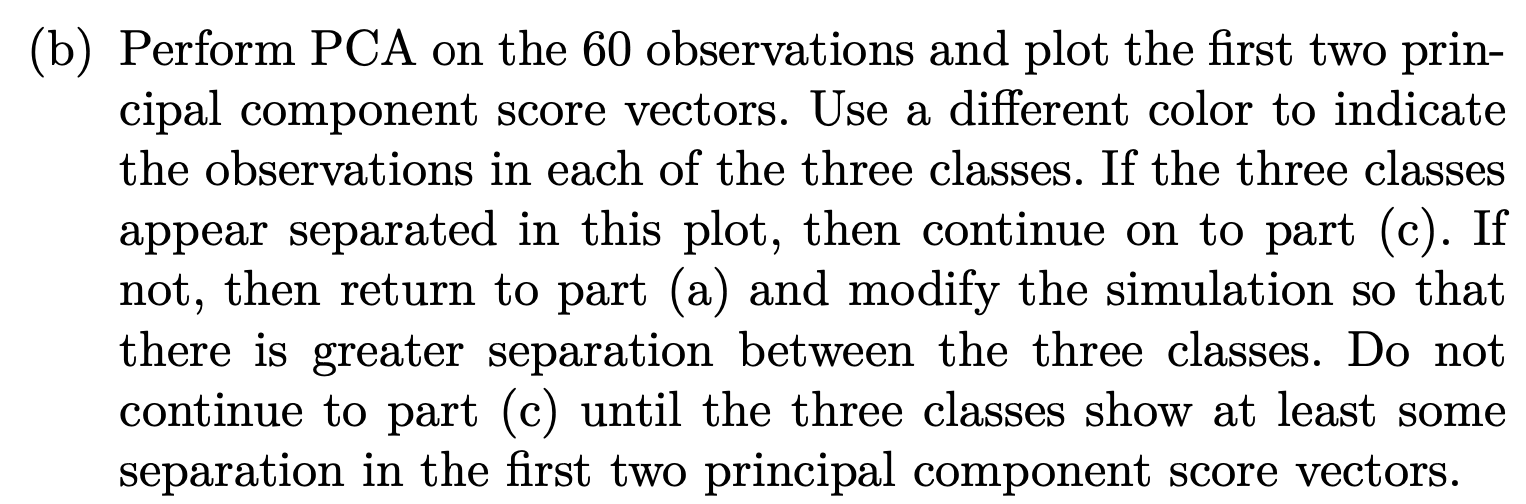

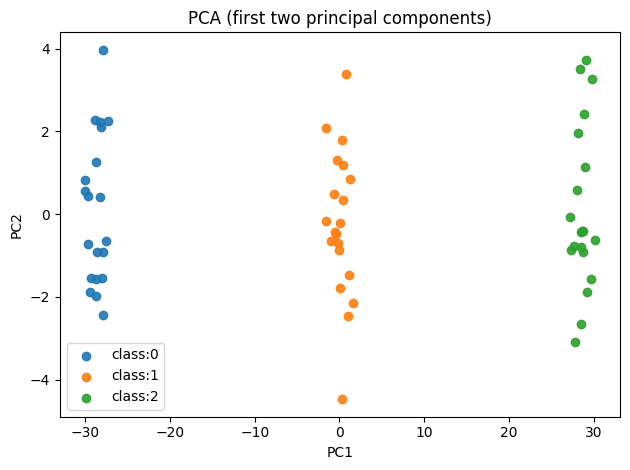

In [ ]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
Z = pca.fit_transform(x)

plt.figure()
label_names = {0: "class:0", 1: "class:1", 2: "class:2"}
for cls in np.unique(y):
    idx = (y == cls)
    plt.scatter(Z[idx, 0], Z[idx, 1], alpha=0.9, label=label_names.get(cls, f"Class {cls}"))
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA (first two principal components)")
plt.legend()
plt.tight_layout()
plt.show()

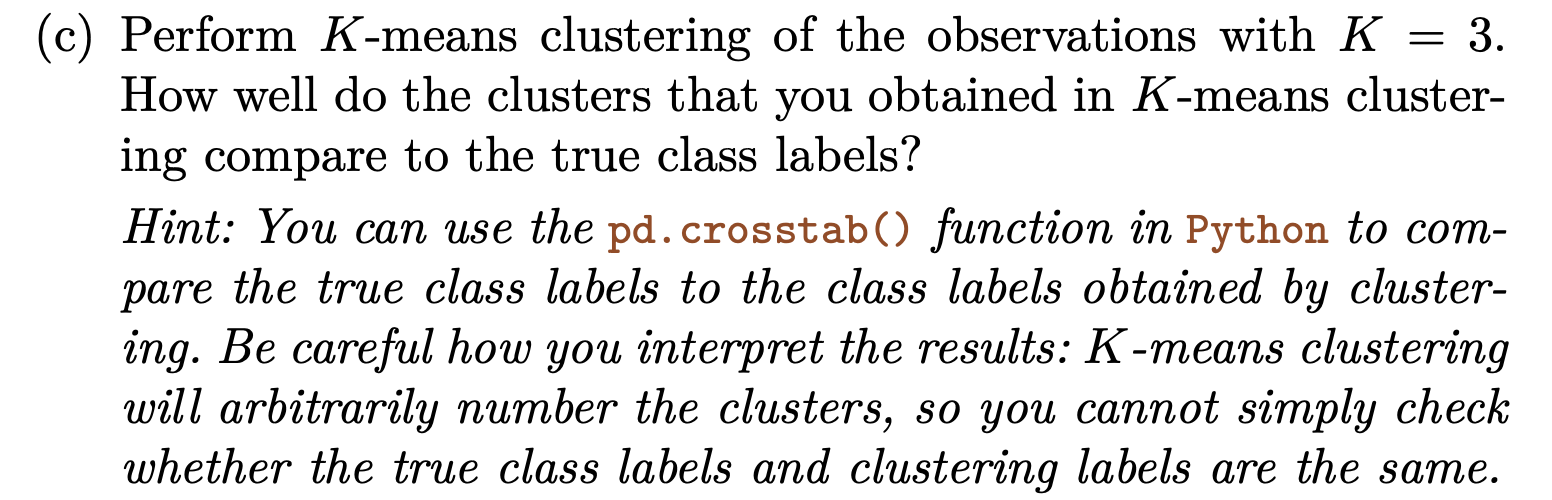

In [ ]:
def plot_clusters_on_pca(X, cluster, title="Clusters on PCA(2)"):
    Z = PCA(n_components=2).fit_transform(X)
    plt.figure()
    for c in np.unique(cluster):
        idx = (cluster == c)
        plt.scatter(Z[idx,0], Z[idx,1], alpha=0.9, label=f"cluster {c}")
    plt.xlabel("PC1"); plt.ylabel("PC2"); plt.title(title)
    plt.legend(); plt.tight_layout(); plt.show()

Cluster   0   1   2
True               
0         0  20   0
1        20   0   0
2         0   0  20


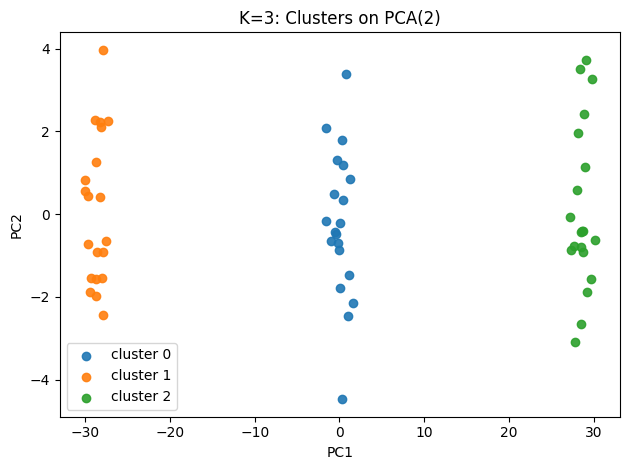

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, adjusted_mutual_info_score
cluster3 = KMeans(n_clusters=3, n_init=10).fit_predict(x)


ct3 = pd.crosstab(pd.Series(y, name="True"),pd.Series(cluster3, name="Cluster"))

print(ct3)

plot_clusters_on_pca(x, cluster3, "K=3: Clusters on PCA(2)")


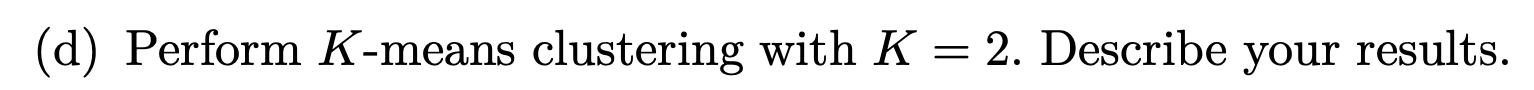

Cluster   0   1
True           
0         0  20
1        20   0
2        20   0


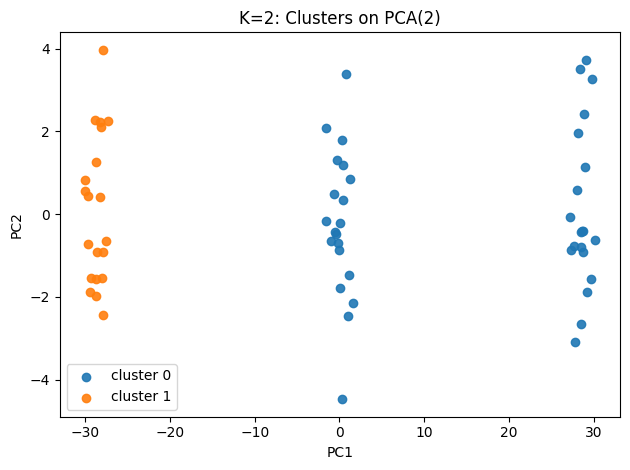

In [ ]:
cluster2 = KMeans(n_clusters=2, n_init=10).fit_predict(x)
ct2 = pd.crosstab(pd.Series(y, name="True"),pd.Series(cluster2, name="Cluster"))

print(ct2)
plot_clusters_on_pca(x, cluster2, "K=2: Clusters on PCA(2)")

two true classes are merged into a single cluster, indicating under-clustering

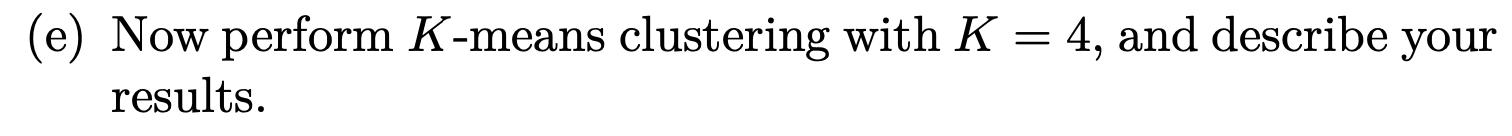

Cluster   0  1   2   3
True                  
0        20  0   0   0
1         0  0  20   0
2         0  9   0  11


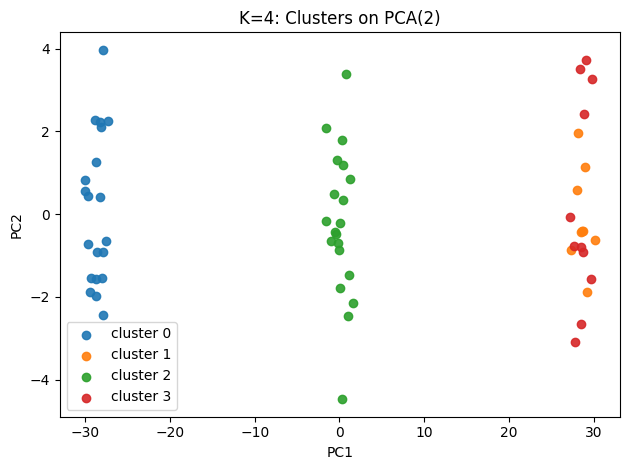

In [ ]:
cluster4 = KMeans(n_clusters=4, n_init=10).fit_predict(x)

ct4 = pd.crosstab(pd.Series(y, name="True"),pd.Series(cluster4, name="Cluster"))

print(ct4)
plot_clusters_on_pca(x, cluster4, "K=4: Clusters on PCA(2)")

With K=4, the crosstab shows that one true class is split into two clusters, indicating over-clustering

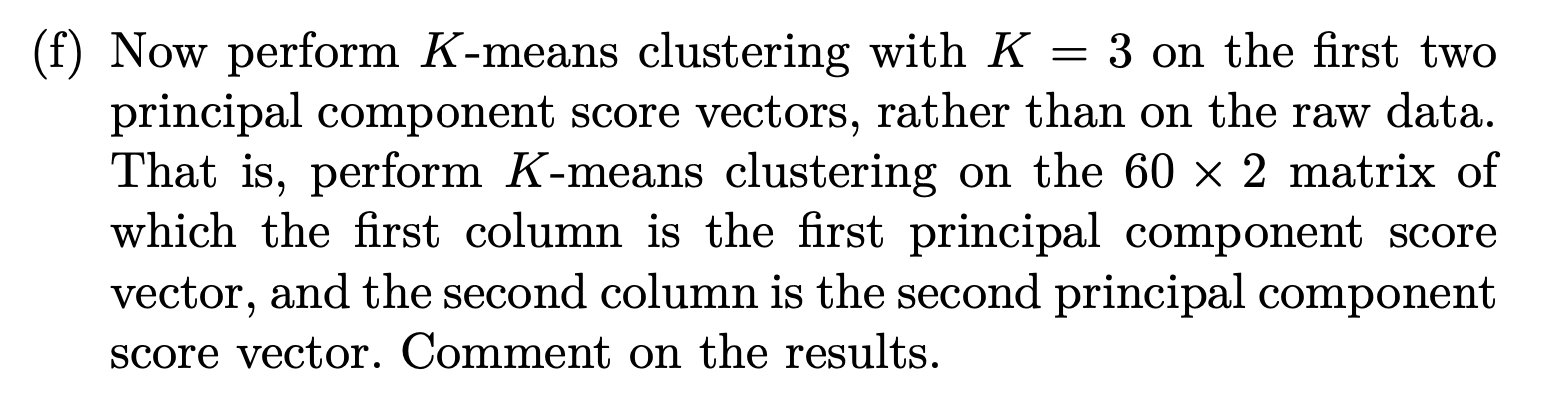

Cluster (PC12)   0   1   2
True                      
0               20   0   0
1                0   0  20
2                0  20   0


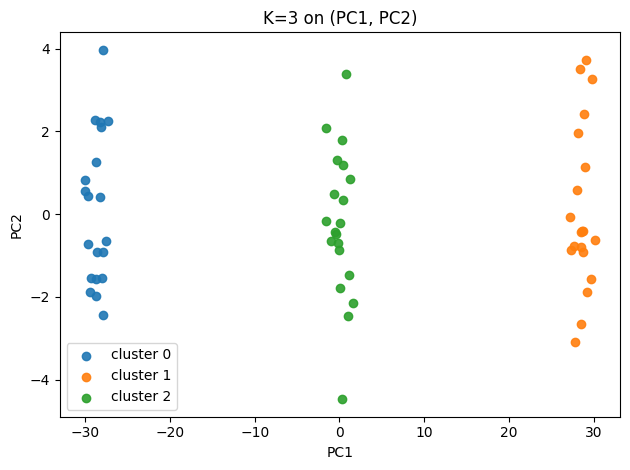

In [ ]:
pca = PCA(n_components=2)
Z = pca.fit_transform(x)

km_pca = KMeans(n_clusters=3, n_init=10)
cluster_pcs = km_pca.fit_predict(Z)
ct = pd.crosstab(pd.Series(y, name="True"), pd.Series(cluster_pcs, name="Cluster (PC12)"))
print(ct)

plot_clusters_on_pca(x, cluster_pcs, "K=3 on (PC1, PC2)")

# plt.figure()
# for c in np.unique(cluster_pcs):
#     idx = (cluster_pcs == c)
#     plt.scatter(Z[idx,0], Z[idx,1], label=f"cluster {c}", alpha=0.9)
# plt.xlabel("PC1"); plt.ylabel("PC2"); plt.title("K=3 on (PC1, PC2)")
# plt.legend(); plt.tight_layout(); plt.show()

K-means on PC1–PC2 yields essentially the same clustering as (c), because PC1 already captures the class separation, so reducing to two PCs removes noise without losing the signal.

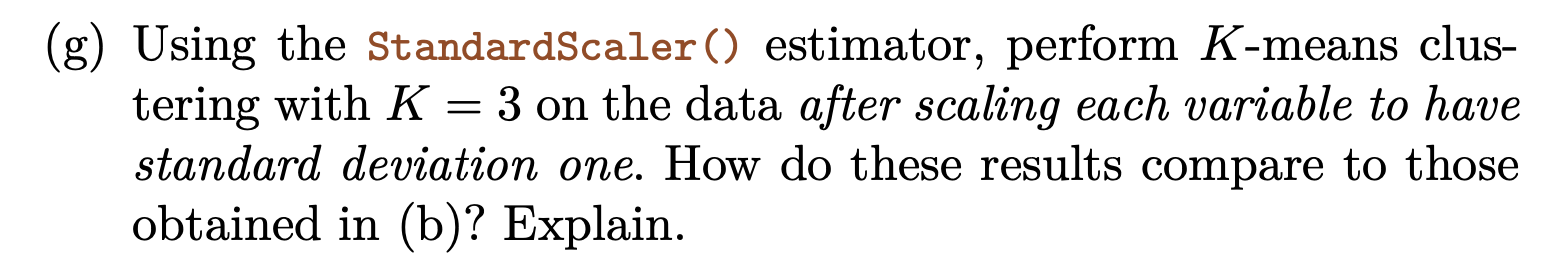

Cluster (scaled)   0   1   2
True                        
0                 20   0   0
1                  0   0  20
2                  0  20   0


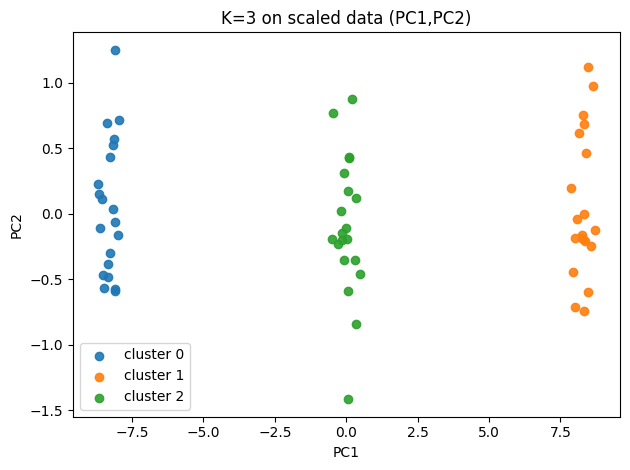

In [ ]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
x_scaled = sc.fit_transform(x)

km_scaled = KMeans(n_clusters=3, n_init=10)
cluster_scaled = km_scaled.fit_predict(x_scaled)

compare_scaled = pd.crosstab(pd.Series(y, name="True"),
                        pd.Series(cluster_scaled, name="Cluster (scaled)"))

print(compare_scaled)

plot_clusters_on_pca(x_scaled, cluster_scaled, "K=3 on scaled data (PC1,PC2)")

K-means yields nearly the same clusters because features already had similar variance and class separation was large; in general, scaling equalizes feature weights and prevents high-variance features from dominating distance.